# Cross Validation, Model Selection & Regularisation

Signification des émoticones :
- 🌞 : documentations importantes
- 👀 : documentations intéressantes à connaître
- 🌚 : en complément
- (vide) : à vous de voir

In this notebook we will introduce the concepts below, and how they can be implemented in `scikit-learn`.
* Cross validation - a method for estimating the test error rate when test data is not available
* Model selection - how we use cross validation to select which model (from a selection) we should use for a particular data set
* Regularisation - an adaptation of linear regression to make it more flexible

[This video](https://www.youtube.com/watch?v=DQWI1kvmwRg) describes some of the ideas you will face in the coming notebook. The ideas we are covering here are described much more throughly in **ISLR** (see suggested sections in module overview).

🌚 https://trevorhastie.github.io/ISLR/

In [97]:
import pandas as pd
import numpy as np

## Cross validation

We have already seen the notion of splitting *test* and *training sets* in order to asses model performance. Now we will introduce the idea of *validation sets*.

Once again **ISTL** (Section 5.1) provides a very clear overview of how these techniques work:

>Resampling methods are an indispensable tool in modern statistics. They
involve repeatedly drawing samples from a training set and refitting a model
of interest on each sample in order to obtain additional information about
the fitted model. For example, in order to estimate the variability of a linear
regression fit, we can repeatedly draw different samples from the training
data, fit a linear regression to each new sample, and then examine the
extent to which the resulting fits differ. Such an approach may allow us to
obtain information that would not be available from fitting the model only
once using the original training sample.

>Resampling approaches can be computationally expensive, because they
involve fitting the same statistical method multiple times using different
subsets of the training data. However, due to recent advances in computing
power, the computational requirements of resampling methods generally
are not prohibitive. [...] cross-validation can be used to estimate the test
error associated with a given statistical learning method in order to evaluate
its performance, or to select the appropriate level of flexibility. The process
of evaluating a model’s performance is known as model assessment, whereas model
the process of selecting the proper level of flexibility for a model is known as assessment
model selection.

The diagram below illustrates this process. Here the train and validation sets are used to do model assesment and model selection (NOTE: the test set is strictly forbidden from being used in any way during this process!). Once a model is selected the test set is used to do a final assesment of performance to see if the model selected will generalise as well as predicted.

<img src="./images/testtrainvalid.png" width="450px">

There is a simple overview these ideas 👀[here](https://towardsdatascience.com/training-vs-testing-vs-validation-sets-a44bed52a0e1/), and a more thorough overview 🌚[here](https://machinelearningmastery.com/difference-test-validation-datasets/).

🌞 This video of Machine learnia also explains the concept of cross validation very well : https://www.youtube.com/watch?v=w_bLGK4Pteo&ab_channel=MachineLearnia

### K-fold cross validation

A very common method called *k-fold* is often used, which actually splits the training set multiple times. This allows us to assess the accuracy of the model over $k$ validation splits of data. The 🌚[image below](http://ethen8181.github.io/machine-learning/model_selection/model_selection.html) illustrates how this works for $k = 5$ splits.

<img src="./images/kfold.png" width="450px">

The `scikit-learn` documentation offers a simple 🌞[example](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html) of implementing k-fold on some dummy data. We will examine this below. NOTE: The `scikit-learn` documentation is **FANSTASTIC(!)** and contains working examples of every function, it should always be the first place you look when you wish to implement a new function.

**Task 1:** 

* Have a look at the code below and check you understand what is going on. (Add some print statements in various places to help.)

In [98]:
import numpy as np
from sklearn.model_selection import KFold
X = np.array([['A', 'B'], ['C', 'D'], ['E', 'F'], ['G', 'H']])
y = np.array([1, 2, 3, 4])
kf = KFold(n_splits=3) # here we choose the number of folds (or splits) we will make
kf.get_n_splits(X)

print("splits : ", 3)

for train_index, valid_index in kf.split(X): # kf.split(X) is an iterable which gives us the indices of the data in each fold
    print("TRAIN indices:", train_index, "VALIDATION indices:", valid_index, "\n")
    X_train, X_valid = X[train_index], X[valid_index]
    y_train, y_valid = y[train_index], y[valid_index]

    print("TRAIN:", X_train, "\nVALIDATION:", X_valid, "\n")

splits :  3
TRAIN indices: [2 3] VALIDATION indices: [0 1] 

TRAIN: [['E' 'F']
 ['G' 'H']] 
VALIDATION: [['A' 'B']
 ['C' 'D']] 

TRAIN indices: [0 1 3] VALIDATION indices: [2] 

TRAIN: [['A' 'B']
 ['C' 'D']
 ['G' 'H']] 
VALIDATION: [['E' 'F']] 

TRAIN indices: [0 1 2] VALIDATION indices: [3] 

TRAIN: [['A' 'B']
 ['C' 'D']
 ['E' 'F']] 
VALIDATION: [['G' 'H']] 



We can apply this to any data set to perform operations as it gives us the dataframe/numpy array indicies in each loop to select the appropriate data for each fold. For example we can apply this to the auto data set. This contains rows which correspond to individual cars and their attributes.

In [99]:
auto = pd.read_csv('./data/Auto.csv')
auto = auto[auto.horsepower != '?']
auto['horsepower'] = auto.horsepower.astype(int)
auto.reset_index(inplace=True, drop=True)
auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [100]:
mpg = auto.pop('mpg') # mpg will be our target and so we remove this into a seperate array

Say we are trying to predict 'mpg' from our other automobile data features. We can use KFold to iterate over the number of splits we choose.

**Task 2:**
* try adding print statements for the size of the dataframes in each split
* try increasing the number of splits and re-run your code
* use the code below to print a car name contained in the train and validation data set, for each split



In [101]:
kf = KFold(n_splits=10) # here we choose the number of folds (or splits) we will make
kf.get_n_splits(auto)

print(kf)

split_counter = 1
for train_index, valid_index in kf.split(auto): # kf.split(X) is an iterable which gives us the indices of the data in each fold
    print('-'*60)
    print('This is split no: {}'.format(split_counter))
    split_counter += 1 
    X_train, X_valid = auto.iloc[train_index], auto.iloc[valid_index] # must use .iloc because its a dataframe this time
    y_train, y_valid = mpg[train_index], mpg[valid_index]
    
    # your code here
    print('X_train size : {0}\nX_valid size : {1}'.format(X_train.shape,X_valid.shape))
    print('car name : {0}\ncar name : {1}'.format(X_train['name'].values[0],X_valid['name'].values[0]))

KFold(n_splits=10, random_state=None, shuffle=False)
------------------------------------------------------------
This is split no: 1
X_train size : (352, 8)
X_valid size : (40, 8)
car name : plymouth fury iii
car name : chevrolet chevelle malibu
------------------------------------------------------------
This is split no: 2
X_train size : (352, 8)
X_valid size : (40, 8)
car name : chevrolet chevelle malibu
car name : plymouth fury iii
------------------------------------------------------------
This is split no: 3
X_train size : (353, 8)
X_valid size : (39, 8)
car name : chevrolet chevelle malibu
car name : datsun 510 (sw)
------------------------------------------------------------
This is split no: 4
X_train size : (353, 8)
X_valid size : (39, 8)
car name : chevrolet chevelle malibu
car name : volvo 144ea
------------------------------------------------------------
This is split no: 5
X_train size : (353, 8)
X_valid size : (39, 8)
car name : chevrolet chevelle malibu
car name : bui

In [102]:
auto = auto.drop('name', axis=1, errors='ignore') # we do not need the car names so remove for now.

We can use the same loop to fit and evaluate our linear regression model on each train/validation split:

In [103]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


split_counter = 1
mse_scores = [] # create empty list to append mse scores for each split
kf = KFold(n_splits=5)
kf.get_n_splits(auto)

for train_index, valid_index in kf.split(auto): # kf.split(X) is an iterable which gives us the indices of the data in each fold
    print('-'*60)
    print('This is split no: {}'.format(split_counter))
    print('Model results')
    split_counter += 1 
    X_train, X_valid = auto.iloc[train_index], auto.iloc[valid_index] # must use .iloc because its a dataframe this time
    y_train, y_valid = mpg[train_index], mpg[valid_index]
    
    
    #### fit polynomial to train data in this split
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)
    
    #### eval & print MSE training results in this split
    mpg_train_pred = lin_reg.predict(X_train)
    mse_train = mean_squared_error(y_train, mpg_train_pred)
    print('training MSE: {0}'.format(mse_train))
    
    #### do the same for validation split
    mpg_valid_pred = lin_reg.predict(X_valid)
    mse_valid = mean_squared_error(y_valid, mpg_valid_pred)
    print('validation MSE: {0}'.format(mse_valid))
    
    mse_scores.append(mse_valid) # assign validation MSE score to list

------------------------------------------------------------
This is split no: 1
Model results
training MSE: 11.284070590566003
validation MSE: 14.974307651304223
------------------------------------------------------------
This is split no: 2
Model results
training MSE: 11.155158050598773
validation MSE: 10.905952427081177
------------------------------------------------------------
This is split no: 3
Model results
training MSE: 12.16010513687152
validation MSE: 5.991708610108178
------------------------------------------------------------
This is split no: 4
Model results
training MSE: 9.921674145405687
validation MSE: 15.587544657621583
------------------------------------------------------------
This is split no: 5
Model results
training MSE: 7.977511689294956
validation MSE: 27.844743081984188


When using k-fold cross validation we can analyse the validation MSE result for each split to assess the overall performance.

In [104]:
mse_scores  = np.array(mse_scores)
print('VALIDATION SET MSE SCORES')
print('mean MSE:', mse_scores.mean())
print('std MSE:', mse_scores.std())

VALIDATION SET MSE SCORES
mean MSE: 15.06085128561987
std MSE: 7.255691814890921


#### Cross validation in practice in sklearn
Most of the time we do not care about having access to each split. `Scikit-Learn` provide a much easier way to do all of this with the function `cross_val_score`. This allows us to do the same as above but in much less code.

In [105]:
from sklearn.model_selection import cross_val_score
lin_reg = LinearRegression()

cv_scores = cross_val_score(lin_reg, auto, mpg, cv = 5, scoring='neg_mean_squared_error') 

print('mean MSE:',np.mean(-cv_scores))
print('std MSE:',np.std(-cv_scores))

mean MSE: 15.06085128561987
std MSE: 7.255691814890921


In [106]:
cv_scores

array([-14.97430765, -10.90595243,  -5.99170861, -15.58754466,
       -27.84474308])

**Task 3:**

* Make sure you understand the output of the cross_val_score above (i.e. What is cv_scores?)
* Why is the scoring defined as negative MSE? Do some research
* Investigate what the `cross_val_predict` function does.
* Import and implement `cross_val_predict`on the same data as above.
* What are the outputs of this function?
* Can you use these to evaluate the results of your cross validation?
* Do the cross-validation scores give you confidence this model is providing a useful prediction?

MSE : 15.050031279260548
R2 : 0.7523147957930156


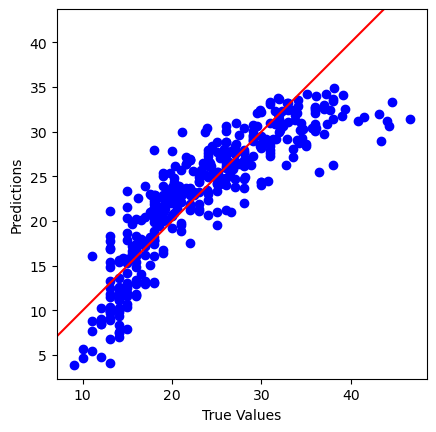

In [107]:
# solution

# The ouput of cv_scores is the mean squared error for each fold, but negated.
# the closest to zero the better the model.

# cross_val score is negative because by convention in sklearn, all scorers follow the convention that higher return values are better than lower return values. 
# Since MSE is a loss function (the lower the better), it is negated to follow this convention

# cross_val_predict gives the predicted values for each data point when it was in the validation fold.

from sklearn.model_selection import cross_val_predict
lin_reg = LinearRegression()
predicted = cross_val_predict(lin_reg, auto, mpg, cv=5)
predicted[:5]

# the ouput shows the predicted mpg values for each car in the dataset.

# evaluating the results
from sklearn.metrics import r2_score

mse = mean_squared_error(mpg, predicted)
r2 = r2_score(mpg, predicted)

print("MSE :", mse)
print("R2 :", r2)

# plotting the results
import matplotlib.pyplot as plt
plt.scatter(mpg, predicted, color=['blue'])
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.axis('equal')
plt.axis('square')
plt.xlim(plt.xlim())
plt.ylim(plt.ylim())
_ = plt.plot([0, 60], [0, 60], color='red')

# the cvscores gives us confidence that the model is performing well and is not overfitting.

## Exercise 1: wine cross-validation

You must predict the alcohol content of various wines based on their other attributes.

* Split the data into train and test data sets (Ensure you use the option: `random_state = 28`).
* Perform linear regression using k-fold cross validation(ensure you use 5 folds). Return the cross validation MSE errors. Return the mean and standard deviations of these.
* Evaluate the performance of the model on the test set.
* Compare the cross-validation error and the test error (MSE). What do you find? 
* Try removing the random_state option. What happens to your results? Explain why.

In [108]:
#### your solution here
from sklearn.model_selection import train_test_split

df_wine = pd.read_csv('./data/wine.csv')

X = df_wine.drop('Alcohol', axis=1)
y = df_wine['Alcohol']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=28)

kf = KFold(n_splits=5)
kf.get_n_splits(X)

lin_reg = LinearRegression()

cv_scores = cross_val_score(lin_reg, X, y, cv = 5, scoring='neg_mean_squared_error') 

print('cv scores : ',cv_scores)
print('mean MSE:',np.mean(-cv_scores))
print('std MSE:',np.std(-cv_scores))

# evaluate the performances of the model on the test set
lin_reg.fit(X_train, Y_train)
Y_test_pred = lin_reg.predict(X_test)
mse_test = mean_squared_error(Y_test, Y_test_pred)

print("\nMSE test set :", mse_test)

cv scores :  [-0.49567837 -0.39512765 -0.45152644 -0.71640624 -0.63448917]
mean MSE: 0.5386455734475492
std MSE: 0.11901106398426886

MSE test set : 0.5245292163165451


mse and cverrors are quite similar, which indicates that the model is not overfittin

In [109]:
#### your solution here
from sklearn.model_selection import train_test_split

df_wine = pd.read_csv('./data/wine.csv')

X = df_wine.drop('Alcohol', axis=1)
y = df_wine['Alcohol']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2)

kf = KFold(n_splits=5)
kf.get_n_splits(X)

lin_reg = LinearRegression()

cv_scores = cross_val_score(lin_reg, X, y, cv = 5, scoring='neg_mean_squared_error') 

print('cv scores : ',cv_scores)
print('mean MSE:',np.mean(-cv_scores))
print('std MSE:',np.std(-cv_scores))

# evaluate the performances of the model on the test set
lin_reg.fit(X_train, Y_train)
Y_test_pred = lin_reg.predict(X_test)
mse_test = mean_squared_error(Y_test, Y_test_pred)

print("\nMSE test set :", mse_test)

cv scores :  [-0.49567837 -0.39512765 -0.45152644 -0.71640624 -0.63448917]
mean MSE: 0.5386455734475492
std MSE: 0.11901106398426886

MSE test set : 0.4245893147719574


removing random state makes the split random everytime

## Regularisation

An alternative to choosing models which contains smaller numbers of features is to use a method that *constrains* or *regularises* the coefficent estimates assigned to each feature, or that shrinks the coefficient towards zero. This technique is very similar to *least squares* which we have been using until now. Please refer to Section in 6.2 **ISTL** for a fuller explanation of this.

When we move to use a regularised linear regression for prediction, the additional term means that we now have a model parameter that requires setting or tuning. These terms are referred to as *hyperparameters* in machine learning. In practice this introduces another additional unknown parameter which we must choose somewhere in our modelling. It is common practice to run several models, each with different values of this hyperparameter, and then assess the error of each using cross validation for comparison.

**Lasso vs Ridge** (just for information curiosity, no need to go in depth or spend to much time to understand the maths)

For now we will focus on how to implement Lasso and Ridge regression in sklearn. These are both types of regularised linear regression.

Lasso: objectif is to minimize
$$ RSS + \lambda \sum |\beta | $$
* can force coefficients exactly to zero: behaves thus as variable selection


Ridge: objectif is to minimize
$$ RSS + \lambda \sum \beta_i^2 $$
* does not force coefficients exactly to zero
* interestig when there are more predictors than observations

see further reading ILS, search for Ridge and Lasso

#### Lasso regression in sklearn

In this example we aim to predict credit rating of individual customers. To train and predict using a Lasso regression we follow much the same procedure as we have seen before in `scikit-learn`.

Additional sources for further reading :

👀 https://www.datacamp.com/community/tutorials/tutorial-ridge-lasso-elastic-net

🌚 https://eric.univ-lyon2.fr/ricco/cours/slides/regularized_regression.pdf

In [110]:
credit = pd.read_csv('./data/credit_modified.csv')
rating = credit.pop('Rating')
credit.head()

,Income,Limit,Cards,Age,Education,Gender,Student,Married,Balance,African American,Asian,Caucasian
0,14.891,3606,2,34,11,0,0,1,333,0,0,1
1,106.025,6645,3,82,15,1,1,1,903,0,1,0
2,104.593,7075,4,71,11,0,0,0,580,0,1,0
3,148.924,9504,3,36,11,1,0,0,964,0,1,0
4,55.882,4897,2,68,16,0,0,1,331,0,0,1


In [111]:
#### splitting train and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(credit, rating, random_state = 91)

In [112]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha = 1)
cv_scores = cross_val_score(lasso, X_train, y_train, cv = 5, scoring='neg_mean_squared_error')
print('mean MSE:',np.mean(-cv_scores))
print('std MSE:',np.std(-cv_scores))

mean MSE: 103.58909707156693
std MSE: 12.1009734685939


Here we can alter the alpha parameter to change the amount of regularisation the model uses (try this yourself! - vary the value by at least factors of 10). With increases in regularisation we expect a reduction in the *variance* of the model.

#### Using Lasso with grid search

In practice we do not want to vary hyperparameters by hand to find which value is best (the model with minimum cross validation error). Of course `scikit-learn` has a function that automates this for you. Using `GridSearchCV` we pass a dictionary of parameter values we wish to investigate. The function will fit each model we have listed and calculate the cross validation error of each. It provides all the results through the object it returns.

In [113]:
from sklearn.model_selection import GridSearchCV
lasso = Lasso(max_iter=10000)

param_grid = [
 {'alpha': [0.001, 0.01, 0.1, 1, 3, 10, 100, 1000]}
 ]

grid_search = GridSearchCV(lasso, param_grid, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.007336,0.001299,0.002527,0.000621,0.001,{'alpha': 0.001},-134.693531,-105.857049,-101.376944,-87.569097,-78.913304,-76.137420,-109.786540,-103.885686,-106.104721,-113.455931,-101.778022,16.450021,3
1,0.006745,0.001295,0.003306,0.001314,0.010,{'alpha': 0.01},-134.553201,-105.948212,-101.096381,-87.881139,-78.937345,-76.585584,-109.682491,-103.106018,-106.112572,-113.688788,-101.759173,16.329243,2
2,0.005124,0.000853,0.003237,0.001187,0.100,{'alpha': 0.1},-133.132694,-106.809300,-98.722275,-91.394863,-79.351692,-78.012317,-108.680986,-96.604537,-106.093953,-115.062267,-101.386489,15.688554,1
3,0.005291,0.001361,0.002709,0.000792,1.000,{'alpha': 1},-127.851853,-111.017555,-92.827631,-106.006184,-89.048154,-82.339570,-105.158164,-94.934777,-102.310102,-122.139519,-103.363351,13.605513,4
4,0.005598,0.001450,0.002705,0.001196,3.000,{'alpha': 3},-132.499698,-117.173048,-106.238114,-112.301661,-94.847286,-76.537019,-102.509314,-98.851062,-105.902336,-131.338637,-107.819817,15.910751,5


`GridSearchCV` also returns a model (with the best hyperparmeter combination it found) which has been fitted one final time to all of the training data. Therefore it is ready to make predictions on the testing set. The model can be accessed like this:

In [114]:
grid_search.best_estimator_

Lasso(alpha=0.1, max_iter=10000)

**Task 4:**
* How many times will the lasso model be fitted when the GridSearchCV function is called above?

<details><summary>Hint</summary><br>
Check what the `refit=True` parameter does in GridSearchCV
</details>

* Look through the columns of the `grid_results` dataframe. Try and understand what the table contains.

👀 https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

grid search a 10 folds.  
on passe au travers de 8 hyperparamètres.  
Donc on fait 8*10 = 80 fits

## Model selection

Congratulations! You have just done your first model hyperparameter tuning in `scikit-learn`! 

If we have a dataset for which we are interested in developing a predictive model. We do not know beforehand which model will perform best for this particular data or problem. Therefore, we fit and evaluate a number of different models to our data. The models could also be of varying type as well as flexibility (e.g. random forests, support vector machines, linear regression). We then need to decide which of our models we will choose to use in our final product.

As **ISLR** states:
> "we can directly estimate the test error using the validation set and cross-validation methods
discussed in Chapter 5. We can compute the validation set error or the
cross-validation error for each model under consideration, and then select
the model for which the resulting estimated test error is smallest."

This works as a simple rule, which we will follow for the remainder of this notebook. However in practice the selection can sometimes be a bit more nuanced. Read more detail 🌚[here](https://machinelearningmastery.com/a-gentle-introduction-to-model-selection-for-machine-learning/).

#### Task 5: Ridge regression in sklearn

Another type of regularised linear model is know as *Ridge regression*.

* Repeat the model prediction process above on the credit data but use a ridge regression model.
* Try replacing `GridSearchCV` with `RandomizedSearchCV`
* How do these functions differ?

In [115]:
#### Your solution here
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge = Ridge(max_iter=10000)

param_grid = [
 {'alpha': [0.001, 0.01, 0.1, 1, 3, 10, 100, 1000]}
 ]

grid_search = GridSearchCV(ridge, param_grid, cv=10, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

grid_results = pd.DataFrame(grid_search.cv_results_)

grid_results.head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005179,0.001059,0.003346,0.000637,0.001,{'alpha': 0.001},-134.709207,-105.847146,-101.408319,-87.535423,-78.910802,-76.088537,-109.798419,-103.970825,-106.104415,-113.431271,-101.780436,16.463655,6
1,0.005010,0.001160,0.003031,0.000868,0.010,{'alpha': 0.01},-134.708083,-105.847646,-101.405663,-87.537922,-78.910278,-76.089237,-109.797587,-103.951593,-106.104574,-113.432645,-101.778523,16.463002,5
2,0.005255,0.000758,0.003249,0.001152,0.100,{'alpha': 0.1},-134.696920,-105.852592,-101.379213,-87.562901,-78.905195,-76.096104,-109.789211,-103.762049,-106.106093,-113.446278,-101.759656,16.456623,4
3,0.004451,0.001045,0.003150,0.001015,1.000,{'alpha': 1},-134.591854,-105.896229,-101.125522,-87.810393,-78.868133,-76.152928,-109.700721,-102.109819,-106.115508,-113.572360,-101.594347,16.404872,3
4,0.005038,0.001292,0.002803,0.000560,3.000,{'alpha': 3},-134.391253,-105.965205,-100.621625,-88.340987,-78.849639,-76.222951,-109.483397,-99.544295,-106.108819,-113.805661,-101.333383,16.332863,2


In [116]:
grid_search.best_estimator_

Ridge(alpha=10, max_iter=10000)

In [119]:
#### change to randomised search CV
from sklearn.model_selection import RandomizedSearchCV

ridge = Ridge(max_iter=10000)

param_grid = [
 {'alpha': [0.001, 0.01, 0.1, 1, 3, 10, 100, 1000]}
 ]

randomized_search = RandomizedSearchCV(ridge, param_grid, cv=10, scoring='neg_mean_squared_error')
randomized_search.fit(X_train, y_train)

randomized_search_results = pd.DataFrame(randomized_search.cv_results_)

randomized_search_results.head()


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_alpha,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.027133,0.024043,0.007190,0.002454,0.001,{'alpha': 0.001},-134.709207,-105.847146,-101.408319,-87.535423,-78.910802,-76.088537,-109.798419,-103.970825,-106.104415,-113.431271,-101.780436,16.463655,6
1,0.007048,0.003941,0.002903,0.000906,0.010,{'alpha': 0.01},-134.708083,-105.847646,-101.405663,-87.537922,-78.910278,-76.089237,-109.797587,-103.951593,-106.104574,-113.432645,-101.778523,16.463002,5
2,0.005782,0.003577,0.002744,0.000548,0.100,{'alpha': 0.1},-134.696920,-105.852592,-101.379213,-87.562901,-78.905195,-76.096104,-109.789211,-103.762049,-106.106093,-113.446278,-101.759656,16.456623,4
3,0.008732,0.005980,0.003750,0.002169,1.000,{'alpha': 1},-134.591854,-105.896229,-101.125522,-87.810393,-78.868133,-76.152928,-109.700721,-102.109819,-106.115508,-113.572360,-101.594347,16.404872,3
4,0.004693,0.001843,0.003356,0.001270,3.000,{'alpha': 3},-134.391253,-105.965205,-100.621625,-88.340987,-78.849639,-76.222951,-109.483397,-99.544295,-106.108819,-113.805661,-101.333383,16.332863,2


In [121]:
randomized_search.best_estimator_

Ridge(alpha=10, max_iter=10000)

In contrast to GridSearchCV, not all parameter values are tried out, but rather a fixed number of parameter settings is sampled from the specified distributions. The number of parameter settings that are tried is given by n_iter.

## Exercise 2: Moneyball

Moneyball, as well as being a fantastic story, is also a true story of statistical methods being applied in a real world context to make predictions for decision making. [The film Moneyball](https://www.youtube.com/watch?v=-4QPVo0UIzc) is well worth a watch if you have time. As well as in baseball most major competitive sports teams are now using data science to improve their performance, e.g. [football](https://www.isportconnect.com/the-rise-of-data-driven-football-how-ai-and-analytics-are-shaping-the-future-of-the-game/),...

In this excercise you have been hired by Oakland Athletics general manager Billy Beane. Your first mission is to predict the salary each player will make based on other information that is available. This will allow Billy to understand what price he should pay for players in the next transfer season.

You must:
* Import and prepare the data
* Create a train and test set
* Implement a regularised model of your choice (Ridge or Lasso)
* Choose optimal parameters for your regularised model
* Estimate test-error using k-fold cross validation
* Calculate the true test-error
* Run a base line model to compare your model results. Base line model is the most simple approach based on strategy of choice (mean or other). It is then used as reference to conclude whether more complex models are better or not: see DummyRegressor in the sklearn library.

HINT 1
* Some values are missing. You can drop these rows.

HINT 2
* Some columns do not contain numerical values. You can drop these columns. In the Machine Learning model you'll learn more about labeling categorical data

In [ ]:
#### Your solution here
# import the hitters.csv dataset


In [ ]:
# clean data



make train test split

In [ ]:
# make train test split


linear regression model build using CV to estimate what our model performance will be on data it hasnt seen

In [ ]:
##### using k-fold cross val score


In [ ]:
# regularised model - lasso build


In [ ]:
# Print the best hyperparameter for model performance....


**One important thing** to realise is that when we run our `GridSearchCV` for our lasso model we are changing the flexibility of our model and estimating our overall test error. In essence we are estimating this curve below, which we saw in the text book!

<img src="./images/bias_var_tradeoff.png" width="300px">

We can plot our cv values for each of our model flexibilities (alpha values)....

In [ ]:
# plot cv values against alpha parameters

**Task 6:**
* Ridge regression works best when the input variables are standardised. (See section 6.2 **ISLR** for more details.). Try standardising your data before running your model. Do you find different results?
* does this model outperform a simple linear regression model?
* Which variables are most important in the model?
* Make a pairplot or scatter matrix: pd.plotting.scatter_matrix

**These and other things to consider in this problem...**

* We must actually standardise our *X* variables by scaling each *X* by the standard deviation, if not Ridge will not penalise each variable in the same way. We will learn a robust and easy way to do this in the intro to ML module.
* Once our variables are scaled we can use the $\beta$ coefficients that our model finds to see which has a greater influence in our model. We can find as we see below.
* The reason our model does not perform so well is that most of our *X* variables do not have a very clear linear relationship with *y* (see below)! Using non-linear models could be of use in this problem...again we will cover these soon!

In [ ]:
# Your solution here

#standardize data


In [ ]:
# run model and compare with results from non-standardized X


In [ ]:
#### solution plot scatter matrix


## To summarize

* **K-fold cross-validation** splits training data into k subsets, using each as a validation set once. This process estimates model performance and helps select optimal hyperparameters. Finally, the chosen model is evaluated on a separate, held-out test set to assess its generalization ability.

* **cross_val_score** simplifies evaluation by computing metrics (e.g., MSE) across folds, while cross_val_predict generates predictions for each sample.

* **Lasso (L1)** and **Ridge (L2)** regression constrain coefficients to prevent overfitting:
> * Lasso can zero out irrelevant features (feature selection).
> * Ridge shrinks coefficients but rarely to zero, useful when predictors outnumber observations.

* Hyperparameter tuning: **GridSearchCV** automates searching for the optimal regularization strength (alpha) via cross-validation.

* **RandomizedSearchCV** efficiently explores hyperparameters by sampling randomly, unlike exhaustive GridSearchCV.